# **Lab 6**

---
Visualize the filters and feature maps generated by the convolutional layer of a CNN trained on the MNIST dataset.

The notebook displays one original handwritten digit, the convolution filters, and the feature maps produced after applying ReLU.
---
**Deep learning& GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from sklearn.datasets import fetch_openml

In [2]:
mnist, labels = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
mnist = mnist.astype("float32") / 255.0
labels = labels.astype("int64")

images = mnist.reshape(-1, 28, 28)
print("MNIST images shape : ", images.shape)
print("MNIST labels shape : ", labels.shape)

MNIST images shape :  (70000, 28, 28)
MNIST labels shape :  (70000,)


In [3]:
# These are the 3 x 3 filters in the convolutional layer.
convolution_filters = np.array([
    [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]],
    [[-1, -1, -1], [0, 0, 0], [1, 1, 1]],
    [[1, 1, 1], [1, -8, 1], [1, 1, 1]],
    [[1, 0, -1], [0, 0, 0], [-1, 0, 1]]
], dtype="float32")

print("Number of filters : ", len(convolution_filters))
print("Filter shape : ", convolution_filters[0].shape)

Number of filters :  4
Filter shape :  (3, 3)


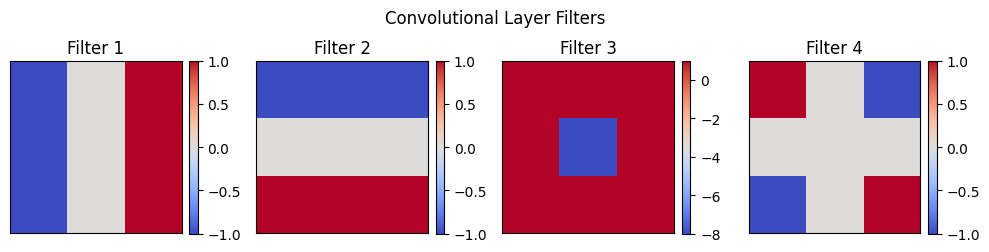

In [4]:
fig, axes = plt.subplots(1, len(convolution_filters), figsize=(10, 2.5))
for index, axis in enumerate(axes):
    image = axis.imshow(convolution_filters[index], cmap="coolwarm")
    axis.set_title(f"Filter {index + 1}")
    axis.set_xticks([])
    axis.set_yticks([])
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.suptitle("Convolutional Layer Filters")
plt.tight_layout()
plt.show()

In [6]:
digit_index = 0
digit = images[digit_index]
digit_label = labels[digit_index]

feature_maps = []
for convolution_filter in convolution_filters:
    convolved = convolve2d(digit, convolution_filter, mode="same")
    relu_feature_map = np.maximum(convolved, 0)
    feature_maps.append(relu_feature_map)

print("Selected digit label : ", digit_label)
print("Number of generated feature maps : ", len(feature_maps))
print("Feature map shape : ", feature_maps[0].shape)

Selected digit label :  5
Number of generated feature maps :  4
Feature map shape :  (28, 28)


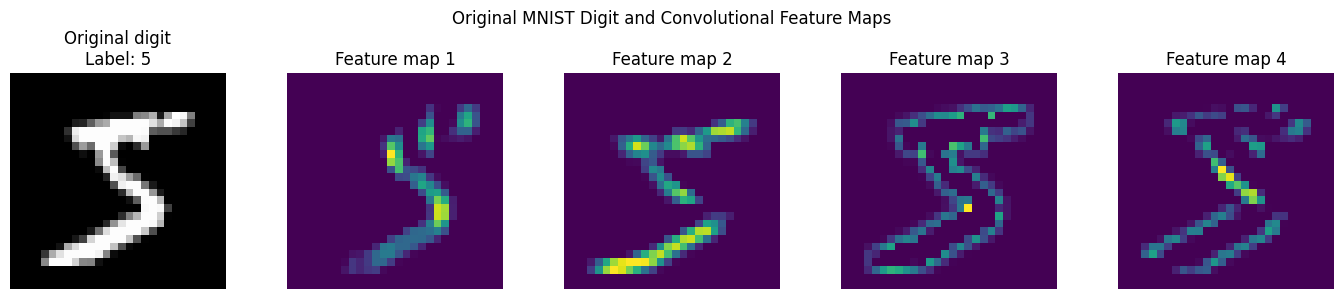

In [7]:
fig, axes = plt.subplots(1, len(feature_maps) + 1, figsize=(14, 3))

axes[0].imshow(digit, cmap="gray")
axes[0].set_title(f"Original digit\nLabel: {digit_label}")
axes[0].axis("off")

for index, feature_map in enumerate(feature_maps):
    axes[index + 1].imshow(feature_map, cmap="viridis")
    axes[index + 1].set_title(f"Feature map {index + 1}")
    axes[index + 1].axis("off")

plt.suptitle("Original MNIST Digit and Convolutional Feature Maps")
plt.tight_layout()
plt.show()